# (IIP314W-2) [2026-T2] OPTIMIZACIÓN APLICADA A NEGOCIOS
## Ayudantía 2: Optimización con restricciones — Pauta (Solución)

---

**Profesor:** Rodrigo Trigo Vilches

**Ayudante:** Vicente Ramírez

**Fecha:** 10 de junio de 2026

**Universidad del Desarrollo**

---

## Objetivos de la ayudantía

- Encontrar y clasificar óptimos en dos variables con el **criterio del Hessiano** (segundo orden).
- Resolver problemas con **restricciones de igualdad** mediante **multiplicadores de Lagrange**.
- Visualizar la **región factible** de un problema con **restricciones de desigualdad** y resolverlo gráficamente, distinguiendo restricciones **activas**, **inactivas** y **redundantes**.
- Confirmar las soluciones con `scipy.optimize` y con `gurobipy`.

## Repaso breve de conceptos

**Criterio de segundo orden (2 variables).** En un punto con $\nabla f = \mathbf{0}$, con el Hessiano $H$ y $D = \det H = f_{xx}f_{yy} - (f_{xy})^2$: si $D>0$ y $f_{xx}>0$ es **mínimo**; si $D>0$ y $f_{xx}<0$ es **máximo**; si $D<0$ es **punto silla**.

**Restricción de igualdad — Lagrange.** Para $\;\min/\max\; f(\vec{x})\;$ sujeto a $\;g(\vec{x}) = c$, se forma el Lagrangiano
$$L(\vec{x},\lambda) = f(\vec{x}) + \lambda\big(g(\vec{x}) - c\big),$$
y se resuelve $\nabla_{\vec{x}} L = \mathbf{0}$ junto con $\dfrac{\partial L}{\partial \lambda} = g(\vec{x}) - c = 0$.

**Restricciones de desigualdad (gráfico).** La **región factible** es la intersección de los semiplanos $g_i(\vec{x}) \le b_i$ y $\vec{x}\ge 0$. En problemas lineales el óptimo se alcanza en un **vértice**. Una restricción es **activa** si se cumple con igualdad en el óptimo (su *holgura* es 0), **inactiva** si sobra holgura, y **redundante** si no aporta al contorno de la región.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

## Ejercicio 1 — Optimización de insumos (Cobb-Douglas)

Una empresa usa dos insumos en cantidades $x>0$ e $y>0$. El **costo neto** (en millones de pesos) que desea minimizar es el costo de los insumos menos el valor de la producción, modelada con una función tipo Cobb-Douglas:

$$f(x,y) = 2x + 2y - 8\,x^{1/4}\,y^{1/2}$$

**Tareas:**
1. Encontrar el punto óptimo $(x^*, y^*)$ resolviendo $\nabla f = \mathbf{0}$.
2. Clasificarlo con el **criterio del Hessiano** (confirmar que es un mínimo).
3. Confirmar la solución con `scipy.optimize.minimize`.
4. Graficar las curvas de nivel marcando el óptimo.

### Solución analítica

$$\nabla f = \left(2 - 2\,x^{-3/4}y^{1/2},\;\; 2 - 4\,x^{1/4}y^{-1/2}\right) = \mathbf{0}$$

De la primera ecuación: $x^{-3/4}y^{1/2} = 1 \Rightarrow y^{1/2} = x^{3/4} \Rightarrow y = x^{3/2}$.

De la segunda: $x^{1/4}y^{-1/2} = \tfrac12 \Rightarrow y^{1/2} = 2x^{1/4} \Rightarrow y = 4x^{1/2}$.

Igualando: $x^{3/2} = 4x^{1/2} \Rightarrow x = 4$, y entonces $y = 4^{3/2} = 8$.

$$\boxed{(x^*, y^*) = (4,\,8)}, \qquad f(4,8) = 8 + 16 - 8\cdot\sqrt{2}\cdot 2\sqrt{2} = 24 - 32 = -8.$$

El criterio de segundo orden (Hessiano definido positivo en el punto, que verificamos abajo) confirma que $(4,8)$ es un **mínimo** del costo neto.

In [2]:
# Verificacion simbolica: gradiente, punto estacionario y criterio del Hessiano
x, y = sp.symbols('x y', positive=True)
f_sym = 2*x + 2*y - 8*x**sp.Rational(1,4)*y**sp.Rational(1,2)

grad = [sp.diff(f_sym, x), sp.diff(f_sym, y)]
sol = sp.solve(grad, (x, y), dict=True)[0]
H = sp.hessian(f_sym, (x, y))
Hopt = H.subs(sol)

print("Gradiente:", grad)
print("Punto optimo:", sol)
print("f(x*, y*) =", sp.nsimplify(f_sym.subs(sol)))
print("Hessiano en el optimo:", Hopt.tolist())
print("det(H) =", float(Hopt.det()), " | H[0,0] =", float(Hopt[0,0]),
      "-> definido positivo => minimo" if Hopt.det() > 0 and Hopt[0,0] > 0 else "")

Gradiente: [2 - 2*sqrt(y)/x**(3/4), -4*x**(1/4)/sqrt(y) + 2]
Punto optimo: {x: 4, y: 8}
f(x*, y*) = -8
Hessiano en el optimo: [[3/8, -1/8], [-1/8, 1/8]]
det(H) = 0.03125  | H[0,0] = 0.375 -> definido positivo => minimo


In [3]:
# Confirmacion numerica con scipy.optimize.minimize
from scipy.optimize import minimize

f_obj = lambda v: 2*v[0] + 2*v[1] - 8*v[0]**0.25*v[1]**0.5
res = minimize(f_obj, x0=[1.0, 1.0], method='Nelder-Mead')
print("scipy -> (x*, y*) =", np.round(res.x, 4), "| f* =", round(res.fun, 4))

scipy -> (x*, y*) = [4. 8.] | f* = -8.0


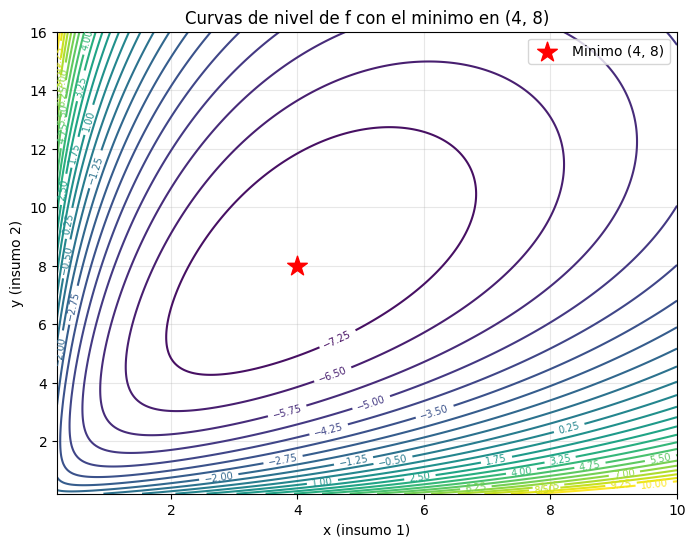

In [4]:
# Grafico: curvas de nivel de f con el minimo
f = lambda x, y: 2*x + 2*y - 8*x**0.25*y**0.5
xv = np.linspace(0.2, 10, 300)
yv = np.linspace(0.2, 16, 300)
X, Y = np.meshgrid(xv, yv)
Z = f(X, Y)

plt.figure(figsize=(8, 6))
cs = plt.contour(X, Y, Z, levels=np.linspace(Z.min(), 10, 25), cmap='viridis')
plt.clabel(cs, inline=True, fontsize=7)
plt.scatter([4], [8], color='red', marker='*', s=220, zorder=5, label='Minimo (4, 8)')
plt.xlabel('x (insumo 1)'); plt.ylabel('y (insumo 2)')
plt.title('Curvas de nivel de f con el minimo en (4, 8)')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

### Discusión

El modelo Cobb-Douglas captura rendimientos decrecientes en cada insumo: el término $8\,x^{1/4}y^{1/2}$ crece cada vez más lento al aumentar $x$ o $y$. Resolviendo $\nabla f = \mathbf{0}$ obtuvimos $(4,8)$, y el criterio de segundo orden (Hessiano definido positivo) confirma que es un **mínimo**. La empresa minimiza su costo neto usando $x^*=4$ e $y^*=8$ unidades de insumo, con un costo neto de $-8$ millones (es decir, una ganancia neta de 8 millones). `scipy` reproduce exactamente el mismo óptimo.

## Ejercicio 2 — Asignación de presupuesto con multiplicadores de Lagrange

Una empresa reparte su inversión entre dos canales de marketing, $x$ e $y$ (en millones de pesos). La **utilidad** generada (en millones) es:

$$U(x,y) = 100x + 80y - 2x^2 - y^2$$

El equipo debe **gastar exactamente** su presupuesto, que en precios de cada canal es:

$$2x + y = 24$$

**Tareas:**
1. Plantear el **Lagrangiano** y resolver el sistema de condiciones de primer orden para hallar $(x^*, y^*, \lambda^*)$.
2. Calcular la utilidad óptima $U(x^*, y^*)$ y verificar que corresponde a un **máximo**.
3. Confirmar con `scipy.optimize.minimize` (método SLSQP).

### Lagrangiano y condiciones de primer orden

$$L(x,y,\lambda) = 100x + 80y - 2x^2 - y^2 + \lambda\,(2x + y - 24)$$

$$\frac{\partial L}{\partial x}: \;100 - 4x + 2\lambda = 0 \qquad
\frac{\partial L}{\partial y}: \;80 - 2y + \lambda = 0 \qquad
\frac{\partial L}{\partial \lambda}: \;2x + y - 24 = 0$$

De $\partial L/\partial y$: $\lambda = 2y - 80$. De $\partial L/\partial x$: $\lambda = 2x - 50$. Igualando, $2x-50 = 2y-80 \Rightarrow y = x + 15$. En la restricción: $2x + (x+15) = 24 \Rightarrow 3x = 9 \Rightarrow x^* = 3$, $y^* = 18$, $\lambda^* = 2(3)-50 = -44$.

$$\boxed{(x^*, y^*) = (3,\,18), \quad \lambda^* = -44, \quad U(3,18) = 300 + 1440 - 18 - 324 = 1398}$$

El Hessiano de $U$ es $\begin{pmatrix}-4&0\\0&-2\end{pmatrix}$ (definido negativo $\Rightarrow$ $U$ cóncava), por lo que el punto hallado es un **máximo**. Además, como $(3,18)$ está en el cuadrante positivo, la **restricción de no negatividad no es activa** (caso a de la Clase 4) y no altera la solución.

In [5]:
# Verificacion simbolica del sistema de Lagrange
x, y, lam = sp.symbols('x y lambda', real=True)
U = 100*x + 80*y - 2*x**2 - y**2
L = U + lam*(2*x + y - 24)

condiciones = [sp.diff(L, x), sp.diff(L, y), sp.diff(L, lam)]
sol = sp.solve(condiciones, (x, y, lam), dict=True)[0]
print("Condiciones de primer orden:", condiciones)
print("Solucion:", sol)
print("U(x*, y*) =", U.subs(sol))

Condiciones de primer orden: [2*lambda - 4*x + 100, lambda - 2*y + 80, 2*x + y - 24]
Solucion: {lambda: -44, x: 3, y: 18}
U(x*, y*) = 1398


In [6]:
# Confirmacion con scipy.optimize.minimize (SLSQP), como en la Clase 4
from scipy.optimize import minimize

neg_U = lambda v: -(100*v[0] + 80*v[1] - 2*v[0]**2 - v[1]**2)   # minimizamos -U
restr = [{'type': 'eq', 'fun': lambda v: 2*v[0] + v[1] - 24}]
noneg = [(0, None), (0, None)]

res = minimize(neg_U, x0=[1.0, 1.0], method='SLSQP', bounds=noneg, constraints=restr)
print("scipy -> (x*, y*) =", np.round(res.x, 4), "| U* =", round(-res.fun, 4))

scipy -> (x*, y*) = [ 3. 18.] | U* = 1398.0


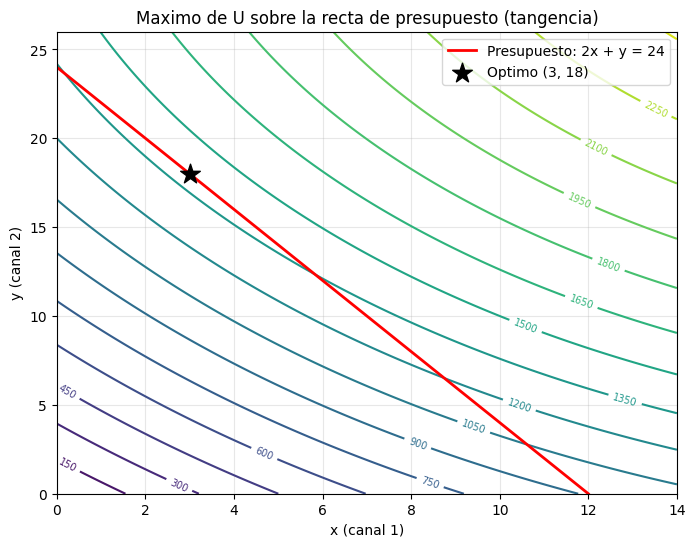

In [7]:
# Grafico: curvas de nivel de U con la recta de presupuesto y el optimo
Uf = lambda x, y: 100*x + 80*y - 2*x**2 - y**2
xv = np.linspace(0, 14, 300)
yv = np.linspace(0, 26, 300)
X, Y = np.meshgrid(xv, yv)

plt.figure(figsize=(8, 6))
cs = plt.contour(X, Y, Uf(X, Y), levels=20, cmap='viridis')
plt.clabel(cs, inline=True, fontsize=7)
xr = np.linspace(0, 12, 100)
plt.plot(xr, 24 - 2*xr, 'r-', lw=2, label='Presupuesto: 2x + y = 24')
plt.scatter([3], [18], color='black', marker='*', s=220, zorder=5, label='Optimo (3, 18)')
plt.xlabel('x (canal 1)'); plt.ylabel('y (canal 2)')
plt.title('Maximo de U sobre la recta de presupuesto (tangencia)')
plt.legend(); plt.grid(alpha=0.3); plt.ylim(0, 26)
plt.show()

### Discusión

El método de Lagrange convierte un problema **con restricción** en un sistema de ecuaciones donde la restricción entra como una variable más ($\lambda$). En el óptimo, las curvas de nivel de $U$ son **tangentes** a la recta de presupuesto (lo vemos en el gráfico), y como $(3,18)$ cae en el cuadrante positivo, la restricción de no negatividad no es activa (caso a de la Clase 4). El multiplicador $\lambda^*$ aparece como subproducto del método; su interpretación económica más fina (la sensibilidad del óptimo ante cambios en el presupuesto) se verá más adelante en el curso.

## Ejercicio 3 — Mezcla de producción con restricciones de desigualdad

Un taller fabrica dos productos, en cantidades $x$ e $y$ (lotes). La **ganancia** por lote es de 4 y 5 (en cientos de miles de pesos), por lo que se busca:

$$\max\; Z = 4x + 5y$$

La producción está limitada por la capacidad de tres procesos:

$$R_1:\; x \le 6 \qquad R_2:\; 3y \le 18 \qquad R_3:\; 2x + 3y \le 24 \qquad x,\,y \ge 0$$

**Tareas:**
1. Graficar la **región factible** y la recta de la función objetivo, y encontrar el vértice óptimo (como en la Clase 5).
2. Indicar qué restricciones quedan **activas** y cuáles **inactivas** en el óptimo.
3. Confirmar con `scipy.optimize.linprog`.
4. Resolver el mismo problema con `gurobipy` y leer las **holguras** (slacks) de las restricciones.

### (a) Región factible y vértice óptimo

La región factible es la intersección de los semiplanos $x\le 6$, $y\le 6$, $2x+3y\le 24$ y $x,y\ge0$. Sus vértices son $(0,0)$, $(6,0)$, $(6,4)$, $(3,6)$ y $(0,6)$. Evaluando $Z=4x+5y$:

| Vértice | $Z = 4x + 5y$ |
|:---:|:---:|
| $(0,0)$ | $0$ |
| $(6,0)$ | $24$ |
| $(6,4)$ | $\mathbf{44}$ |
| $(3,6)$ | $42$ |
| $(0,6)$ | $30$ |

El máximo es $\boxed{(x^*, y^*) = (6,\,4),\; Z^* = 44}$.

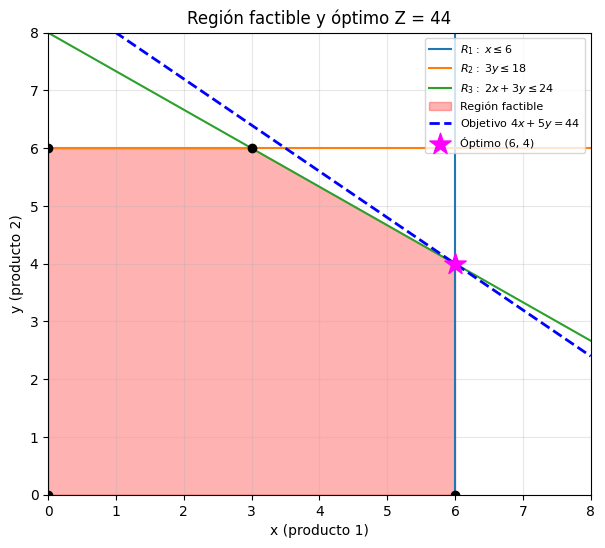

In [8]:
# (a) Region factible, recta objetivo y optimo (estilo Clase 5)
x = np.linspace(0, 8, 400)
r2 = np.full_like(x, 6.0)          # y <= 6  (de 3y <= 18)
r3 = (24 - 2*x) / 3                # 2x + 3y <= 24

plt.figure(figsize=(7, 6))
plt.axvline(6, color='C0', label=r'$R_1:\; x \leq 6$')
plt.plot(x, r2, color='C1', label=r'$R_2:\; 3y \leq 18$')
plt.plot(x, r3, color='C2', label=r'$R_3:\; 2x + 3y \leq 24$')

# region factible: y <= min(6, (24-2x)/3), y >= 0, x en [0,6]
xf = np.linspace(0, 6, 400)
techo = np.minimum(6.0, (24 - 2*xf) / 3)
plt.fill_between(xf, 0, techo, color='red', alpha=0.3, label='Región factible')

# recta de la funcion objetivo en el optimo: 4x + 5y = 44
plt.plot(x, (44 - 4*x) / 5, 'b--', lw=2, label=r'Objetivo $4x+5y=44$')

for vx, vy in [(0,0),(6,0),(6,4),(3,6),(0,6)]:
    plt.scatter([vx], [vy], color='black', zorder=5)
plt.scatter([6], [4], color='magenta', marker='*', s=260, zorder=6, label='Óptimo (6, 4)')

plt.xlim(0, 8); plt.ylim(0, 8)
plt.xlabel('x (producto 1)'); plt.ylabel('y (producto 2)')
plt.title('Región factible y óptimo Z = 44')
plt.legend(loc='upper right', fontsize=8); plt.grid(alpha=0.3)
plt.show()

### (b) Restricciones activas e inactivas

En $(6,4)$:
- $R_1:\; x = 6$  → **activa** (holgura 0).
- $R_2:\; 3y = 12 \le 18$  → **inactiva** (holgura $18-12 = 6$): el proceso 2 no es cuello de botella.
- $R_3:\; 2(6)+3(4) = 24$  → **activa** (holgura 0).

El óptimo queda determinado por $R_1$ y $R_3$; $R_2$ sobra. Si el taller quisiera producir más, debería ampliar la capacidad de $R_1$ o $R_3$, no la de $R_2$.

In [9]:
# (c) Confirmacion con scipy.optimize.linprog (minimiza, por eso -Z)
from scipy.optimize import linprog

c = [-4, -5]                                  # max 4x+5y  ==  min -4x-5y
A_ub = [[1, 0], [0, 3], [2, 3]]               # R1, R2, R3
b_ub = [6, 18, 24]
res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=[(0, None), (0, None)])
print("linprog -> (x*, y*) =", np.round(res.x, 4), "| Z* =", round(-res.fun, 4))
print("Holguras (b - A x):", np.round(np.array(b_ub) - np.array(A_ub) @ res.x, 4))

linprog -> (x*, y*) = [6. 4.] | Z* = 44.0
Holguras (b - A x): [0. 6. 0.]


In [10]:
# (d) Mismo problema con gurobipy
import gurobipy as gp
from gurobipy import GRB

m = gp.Model("mezcla_produccion")
m.setParam('OutputFlag', 0)
x = m.addVar(lb=0, name="x")
y = m.addVar(lb=0, name="y")
R1 = m.addConstr(x <= 6,          name="R1")
R2 = m.addConstr(3*y <= 18,       name="R2")
R3 = m.addConstr(2*x + 3*y <= 24, name="R3")
m.setObjective(4*x + 5*y, GRB.MAXIMIZE)
m.optimize()

print(f"gurobi -> x = {x.X:.4f}, y = {y.X:.4f} | Z* = {m.ObjVal:.4f}")
for c in (R1, R2, R3):
    estado = "activa" if abs(c.Slack) < 1e-9 else "inactiva"
    print(f"  {c.ConstrName}: holgura = {c.Slack:.2f}  ({estado})")

Set parameter Username


Academic license - for non-commercial use only - expires 2027-06-10


gurobi -> x = 6.0000, y = 4.0000 | Z* = 44.0000
  R1: holgura = 0.00  (activa)
  R2: holgura = 6.00  (inactiva)
  R3: holgura = 0.00  (activa)


### Discusión

Gráficamente vemos lo que el profesor mostró en la Clase 5: el óptimo de un problema lineal está en un **vértice** de la región factible, justo donde la recta de la función objetivo "toca" la frontera al desplazarse. Las restricciones **activas** ($R_1$ y $R_3$) son las que definen ese vértice; la **inactiva** ($R_2$) tiene holgura y podría incluso eliminarse sin cambiar la solución. Las holguras que entrega `gurobipy` confirman exactamente este análisis ($0,\,6,\,0$). El tratamiento general de problemas con restricciones de desigualdad (condiciones **KKT**) se verá en la próxima clase.